In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

df = pd.read_csv("station_day.csv", nrows=5)

df.head()

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [8]:
print(df.head())
print(df.shape)
print(df.info())

  StationId        Date  PM2.5    PM10    NO    NO2    NOx    NH3    CO  \
0     AP001  2017-11-24  71.36  115.75  1.75  20.65  12.40  12.19  0.10   
1     AP001  2017-11-25  81.40  124.50  1.44  20.50  12.08  10.72  0.12   
2     AP001  2017-11-26  78.32  129.06  1.26  26.00  14.85  10.28  0.14   
3     AP001  2017-11-27  88.76  135.32  6.60  30.85  21.77  12.91  0.11   
4     AP001  2017-11-28  64.18  104.09  2.56  28.07  17.01  11.42  0.09   

     SO2      O3  Benzene  Toluene  Xylene    AQI AQI_Bucket  
0  10.76  109.26     0.17     5.92    0.10    NaN        NaN  
1  15.24  127.09     0.20     6.50    0.06  184.0   Moderate  
2  26.96  117.44     0.22     7.95    0.08  197.0   Moderate  
3  33.59  111.81     0.29     7.63    0.12  198.0   Moderate  
4  19.00  138.18     0.17     5.02    0.07  188.0   Moderate  
(5, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      ----

In [9]:
print(df.isnull().sum())


StationId     0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           1
AQI_Bucket    1
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df = df.drop_duplicates()


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [14]:
print(df.isnull().sum())


StationId     0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    1
dtype: int64


In [15]:
print(df.describe())

                      Date      PM2.5       PM10        NO        NO2  \
count                    5   5.000000    5.00000  5.000000   5.000000   
mean   2017-11-26 00:00:00  76.804000  121.74400  2.722000  25.214000   
min    2017-11-24 00:00:00  64.180000  104.09000  1.260000  20.500000   
25%    2017-11-25 00:00:00  71.360000  115.75000  1.440000  20.650000   
50%    2017-11-26 00:00:00  78.320000  124.50000  1.750000  26.000000   
75%    2017-11-27 00:00:00  81.400000  129.06000  2.560000  28.070000   
max    2017-11-28 00:00:00  88.760000  135.32000  6.600000  30.850000   
std                    NaN   9.425629   12.17599  2.224347   4.571404   

             NOx        NH3        CO        SO2          O3   Benzene  \
count   5.000000   5.000000  5.000000   5.000000    5.000000  5.000000   
mean   15.622000  11.504000  0.112000  21.110000  120.756000  0.210000   
min    12.080000  10.280000  0.090000  10.760000  109.260000  0.170000   
25%    12.400000  10.720000  0.100000  15.2400

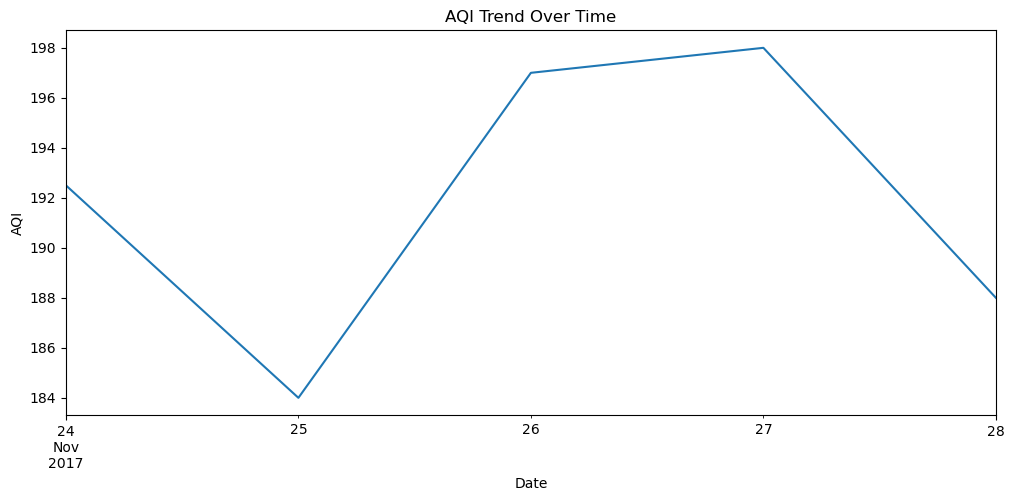

In [16]:
plt.figure(figsize=(12,5))
df.groupby('Date')['AQI'].mean().plot()
plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

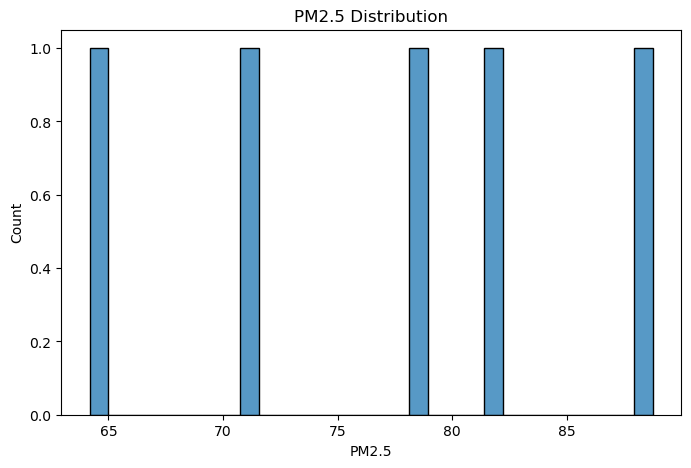

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['PM2.5'], bins=30)
plt.title("PM2.5 Distribution")
plt.show()

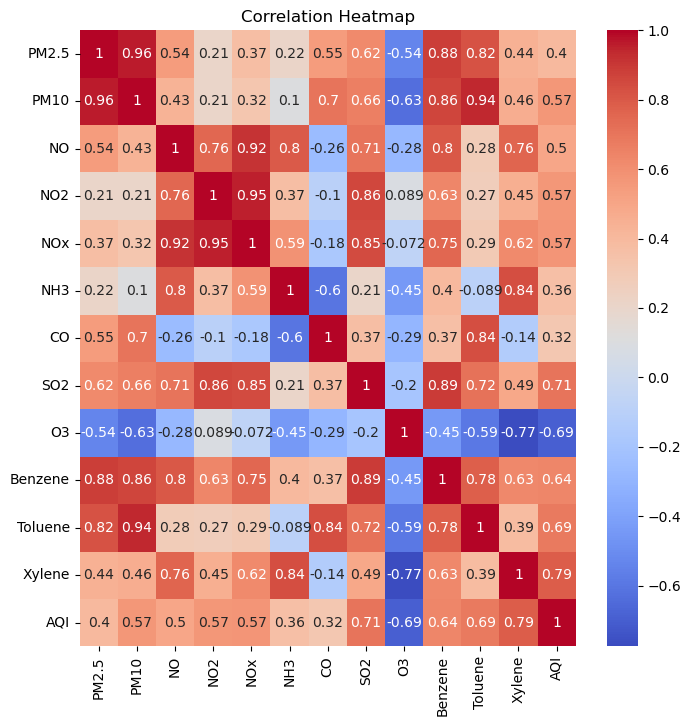

In [19]:
plt.figure(figsize=(8,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

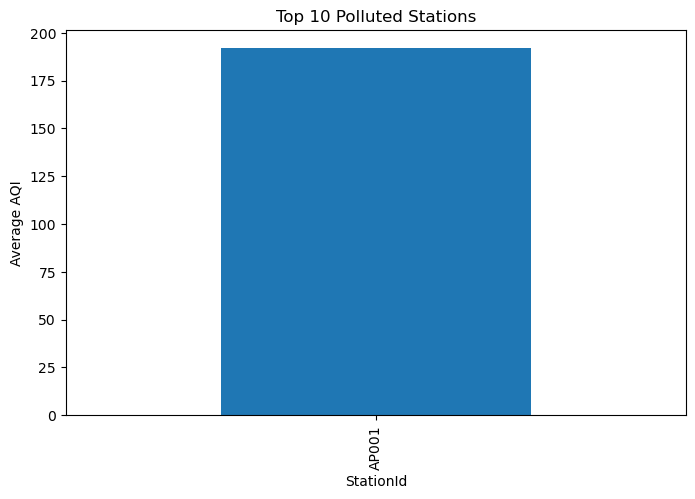

In [21]:
top_stations = df.groupby('StationId')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_stations.plot(kind='bar')
plt.title("Top 10 Polluted Stations")
plt.ylabel("Average AQI")
plt.show()

In [23]:
df.to_csv("station_day_cleaned.csv", index=False)
print("Cleaned file saved successfully!")

Cleaned file saved successfully!
